In [2]:
import CUDA

using RestrictedBoltzmannMachines: RBM, xReLU, log_pseudolikelihood, initialize!, pcd!, sample_from_inputs, free_energy, standardize,
  PottsGumbel, gpu, cpu, sample_v_from_v, sample_h_from_v, load_rbm, save_rbm, StandardizedRBM, dReLU, Potts
using Statistics: mean, cov, var, std
using Random: bitrand
using LinearAlgebra: norm
using Optimisers: Adam
using ProgressMeter: @showprogress
using LogExpFunctions: xlogx
using FASTX.FASTA
using FASTX: identifier, description, sequence
using HDF5
using CairoMakie

In [3]:
fname_msa = "../experiments/datasets/RR/RR.fasta"

msa_sequences = String[]

FASTA.Reader(open(fname_msa)) do reader
    for record in reader
        id = identifier(record)
        desc = description(record)
        seq_string = sequence(String, record)
        push!(msa_sequences, seq_string)
    end
end

println("Number of sequences: ", length(msa_sequences))
println("Length of sequences: ", length(msa_sequences[1]))

Number of sequences: 855395
Length of sequences: 111

Length of sequences: 111


In [4]:
# define the alphabet
tokens = collect("-ACDEFGHIKLMNPQRSTVWY")  # 20 amino acids + gap
ntokens = length(tokens)

# encode the MSA into integer format
nseqs = length(msa_sequences)
seqlen = length(msa_sequences[1])
msa_int = zeros(Int, nseqs, seqlen)
token_to_int = Dict{Char, Int}()
for (i, token) in enumerate(tokens)
    token_to_int[token] = i
end

for i in 1:nseqs
    for j in 1:seqlen
        msa_int[i, j] = token_to_int[msa_sequences[i][j]]
    end
end
println("MSA integer shape: ", size(msa_int))

MSA integer shape: (855395, 111)
855395, 111)


In [5]:
# onehot encode the MSA
function onehot_encode(msa_int, ntokens)
    nseqs, seqlen = size(msa_int)
    msa_onehot = zeros(Bool, ntokens, seqlen, nseqs)
    for i in 1:nseqs
        for j in 1:seqlen
            token_idx = msa_int[i, j]
            msa_onehot[token_idx, j, i] = true
        end
    end
    return msa_onehot
end

msa_onehot = onehot_encode(msa_int, ntokens)
println("MSA onehot shape: ", size(msa_onehot))

MSA onehot shape: (21, 111, 855395)
21, 111, 855395)


In [ ]:
using Random

# Shuffle msa_onehot along the last dimension (sequences)
shuffled_indices = randperm(size(msa_onehot, 3))
msa_onehot = msa_onehot[:, :, shuffled_indices]
println("MSA onehot shuffled")

MSA onehot shuffled


In [28]:
nhidden = 512
rbm_base = RBM(PottsGumbel((ntokens, seqlen)), xReLU((nhidden,)), zeros(ntokens, seqlen, nhidden))
initialize!(rbm_base, msa_onehot)
rbm = gpu(rbm_base);

In [29]:
batchsize = 1024
reg = 0.1
iters = 50000
gibbs_steps = 50
lr = 1e-4


import Dates

function callback(; iter, _...)
    if iszero(iter % 1000)
        # Sample 1000 data points at each call
        nsamples_lpl = min(1000, size(msa_onehot, 3))
        indices = rand(1:size(msa_onehot, 3), nsamples_lpl)
        msa_onehot_subsample = msa_onehot[:, :, indices]
        
        Δt = @elapsed (lpl = mean(log_pseudolikelihood(cpu(rbm), cpu(msa_onehot_subsample))))
        @info "$(Dates.now()) iter=$iter, lpl=$lpl, Δt=$Δt"
    end
end

training_time = @elapsed begin
    state, ps = pcd!(
        rbm, gpu(msa_onehot);
        optim=Adam(lr, (0f0, 999f-3), 1f-6), 
        steps=gibbs_steps, 
        batchsize=batchsize,
        iters=iters,
        vm = gpu(bitrand(size(rbm.visible)..., batchsize)), 
        l2l1_weights=reg,
        callback
    )
end

@show training_time;

fname_out = "../experiments/models/RR/rbm_drelu/rbm_drelu.h5"
save_rbm(fname_out, cpu(rbm), overwrite=true);

[ Info: 2025-12-03T17:06:12.621 iter=1000, lpl=-1.7551938417558566, Δt=0.984207915
[ Info: 2025-12-03T17:10:04.337 iter=2000, lpl=-1.4924600467295739, Δt=0.967486724
[ Info: 2025-12-03T17:10:04.337 iter=2000, lpl=-1.4924600467295739, Δt=0.967486724
[ Info: 2025-12-03T17:13:57.410 iter=3000, lpl=-1.439946604928857, Δt=0.979296568
[ Info: 2025-12-03T17:13:57.410 iter=3000, lpl=-1.439946604928857, Δt=0.979296568
[ Info: 2025-12-03T17:17:53.677 iter=4000, lpl=-1.5333853866258955, Δt=1.118064956
[ Info: 2025-12-03T17:17:53.677 iter=4000, lpl=-1.5333853866258955, Δt=1.118064956
[ Info: 2025-12-03T17:21:51.161 iter=5000, lpl=-1.463942223658428, Δt=1.119278603
[ Info: 2025-12-03T17:21:51.161 iter=5000, lpl=-1.463942223658428, Δt=1.119278603
[ Info: 2025-12-03T17:25:49.089 iter=6000, lpl=-1.4533777143963964, Δt=1.095427543
[ Info: 2025-12-03T17:25:49.089 iter=6000, lpl=-1.4533777143963964, Δt=1.095427543
[ Info: 2025-12-03T17:29:47.978 iter=7000, lpl=-1.4264152216055976, Δt=1.129144879
[ Info: 

training_time = 11998.241779937


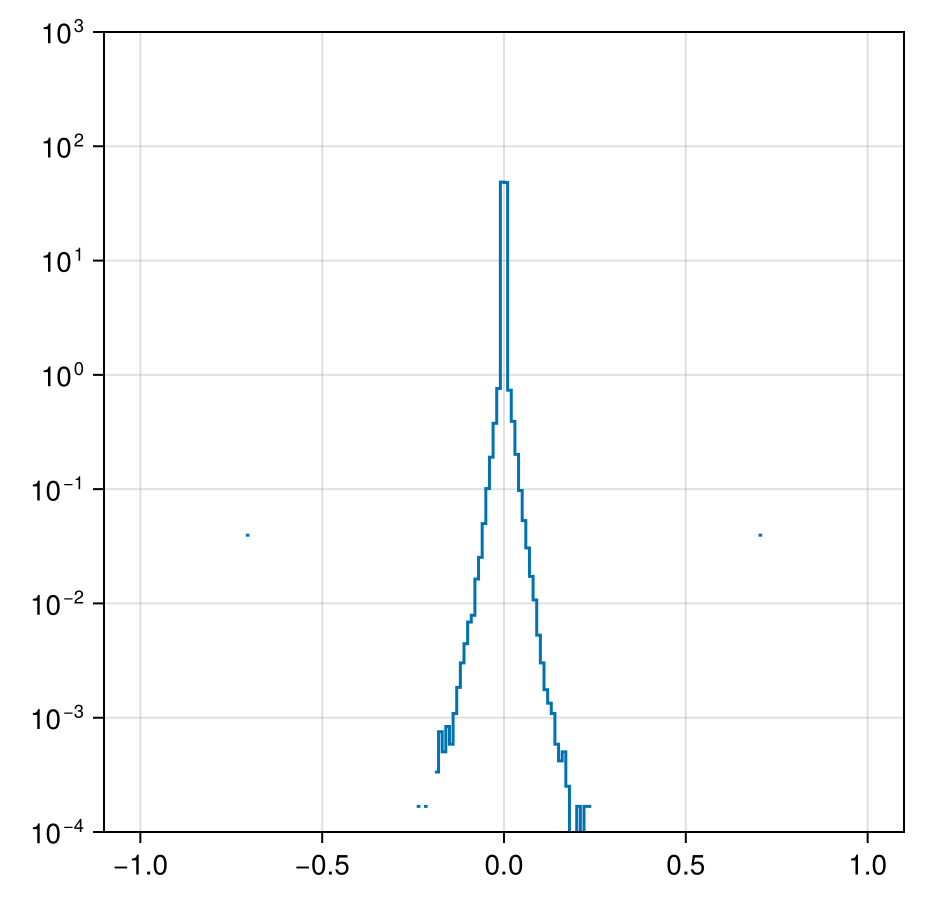

: 

In [ ]:
fig = Makie.Figure()
ax = Makie.Axis(fig[1,1], width=400, height=400, yscale=log10)
Makie.stephist!(ax, vec(cpu(rbm).w), bins=-1:0.01:1, normalization=:pdf)
Makie.ylims!(ax, 1e-4, 1e3)
Makie.resize_to_layout!(fig)
fig

In [31]:
rbm_loaded = load_rbm(fname_out)
rbm_loaded = gpu(rbm_loaded);

In [32]:
sampled_v = sample_from_inputs(gpu(rbm_loaded).visible, gpu(zeros(size(rbm_loaded.visible)..., 2000)));
sampled_f = zeros(1000)
@showprogress for t = 1:length(sampled_f)
    sampled_v .= sample_v_from_v(rbm_loaded, sampled_v; steps=10)
    sampled_f[t] = mean(free_energy(rbm_loaded, sampled_v))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:06
Progress: 100%|█████████████████████████████████████████| Time: 0:01:06


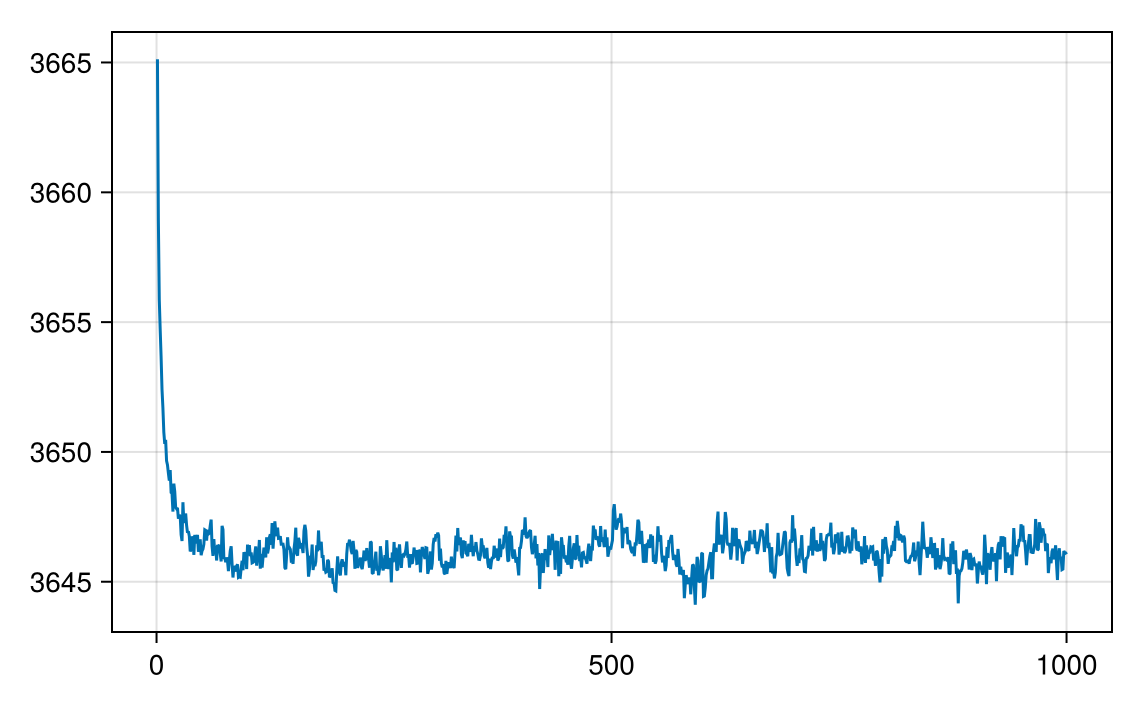

In [33]:
fig = Makie.Figure()
ax = Makie.Axis(fig[1,1], width=500, height=300)
Makie.lines!(ax, sampled_f)
Makie.resize_to_layout!(fig)
fig

In [34]:
function flatcov(data::AbstractArray)
	data_flat = reshape(data, :, size(data)[end])
	C = cov(data_flat; dims=2)
	return [C[i,j] for i = axes(C, 1) for j = axes(C, 2) if i < j]
end

function vh_cov(data_v::AbstractArray{<:Number,3}, data_h::AbstractArray{<:Number,2})
	return reshape(cov(reshape(data_v, :, size(data_v, 3)), data_h; dims=2), size(data_v, 1), size(data_v, 2), size(data_h, 1))
end

vh_cov (generic function with 1 method)

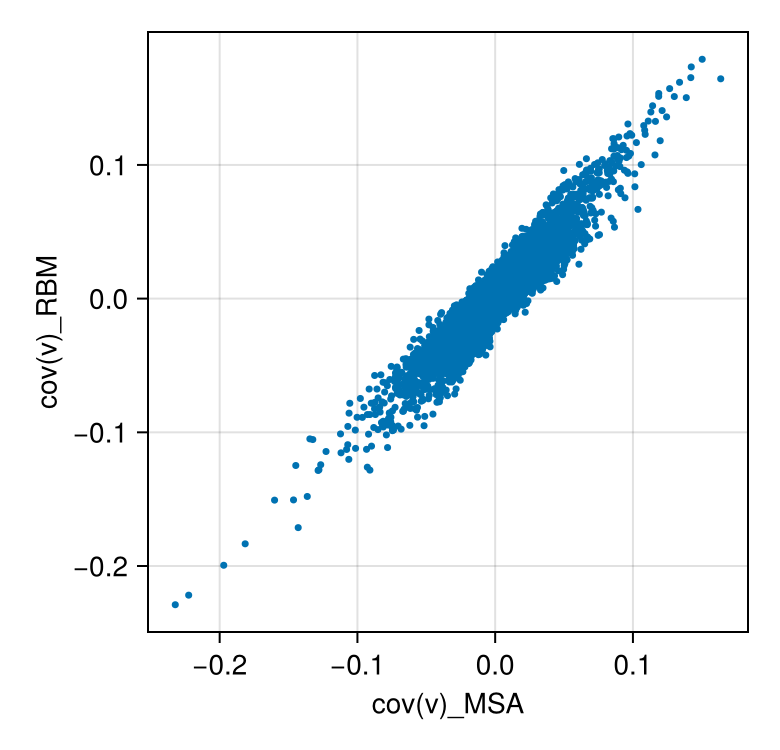

In [35]:
fig = Makie.Figure()
ax = Makie.Axis(fig[1,1], width=300, height=300, xlabel="cov(v)_MSA", ylabel="cov(v)_RBM")
nsamples_data = min(10000, size(msa_onehot, 3))
data_subset = msa_onehot[:, :, 1:nsamples_data]
Makie.scatter!(ax, flatcov(cpu(data_subset)), flatcov(cpu(sampled_v)); markersize=5)
Makie.resize_to_layout!(fig)
fig

In [36]:
# comute pearson correlation between flatcov(cpu(data_subset)) and flatcov(cpu(sampled_v))
using Statistics: cor
pcov = cor(flatcov(cpu(data_subset)), flatcov(cpu(sampled_v)))
@show pcov;

pcov = 0.8663350039165691



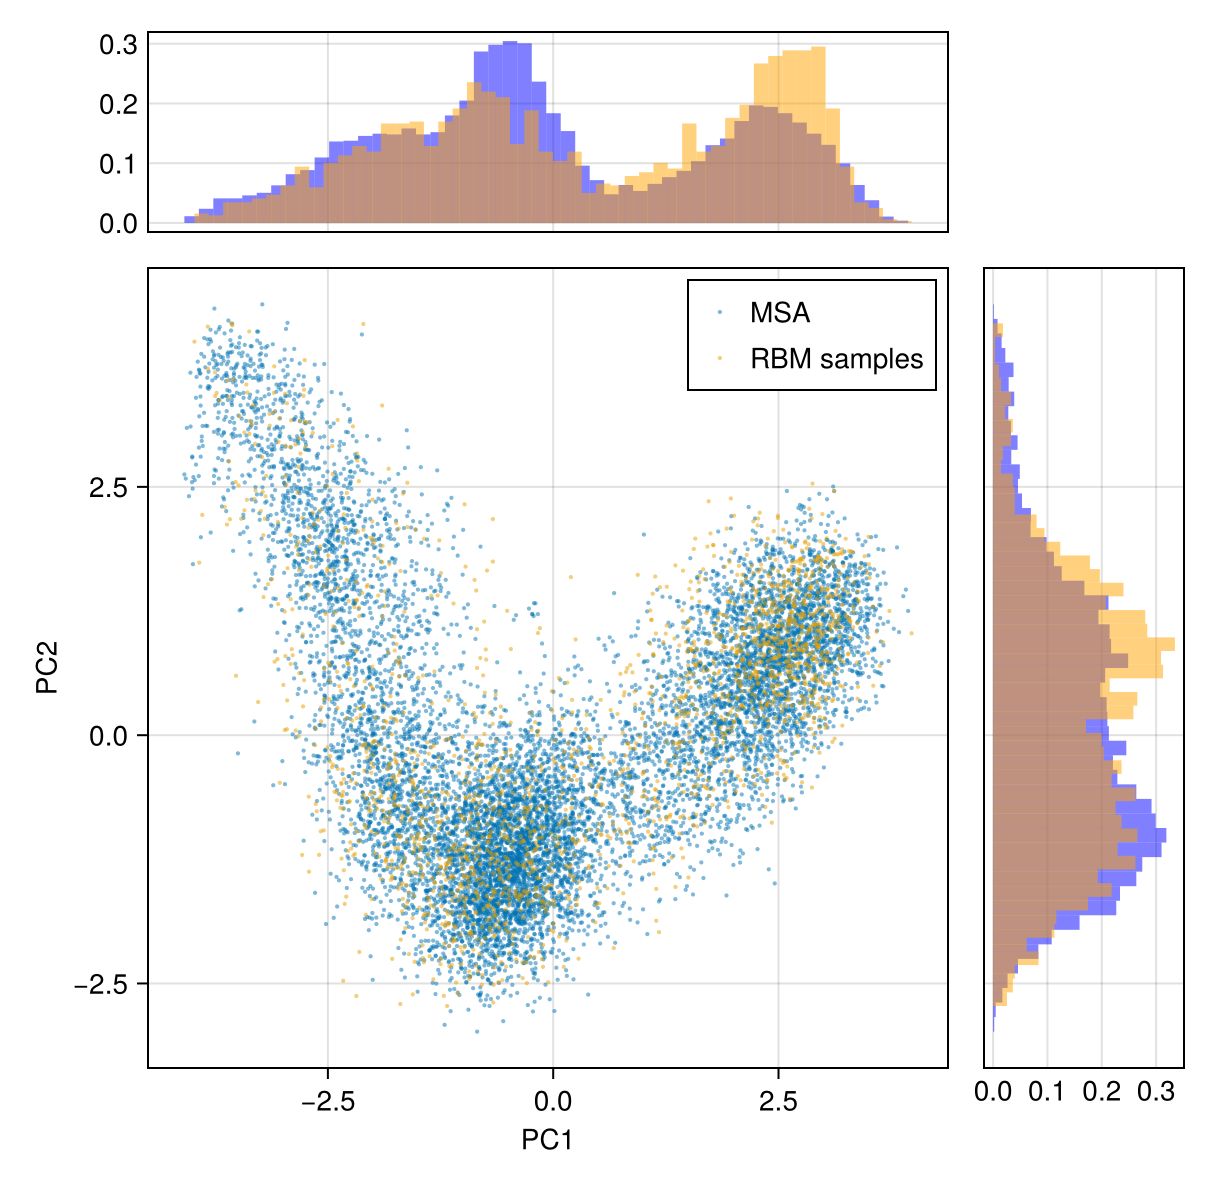

In [37]:
# pca projection of data vs generated samples with marginal histograms

using MultivariateStats

# Select subset of data (10000 samples)
nsamples_data = min(10000, size(msa_onehot, 3))
data_subset = msa_onehot[:, :, 1:nsamples_data]

# Flatten the data for PCA
data_flat = reshape(cpu(data_subset), :, size(data_subset, 3))'
sampled_flat = reshape(cpu(sampled_v), :, size(sampled_v, 3))'

# Fit PCA on the real data
M = fit(PCA, data_flat'; maxoutdim=2)

# Transform both datasets
data_proj = predict(M, data_flat')'
sampled_proj = predict(M, sampled_flat')'

# Plot with marginal histograms
fig = Makie.Figure()
ax_main = Makie.Axis(fig[2,1], width=400, height=400, xlabel="PC1", ylabel="PC2")
ax_top = Makie.Axis(fig[1,1], width=400, height=100, xticklabelsvisible=false, xticksvisible=false, yticksvisible=false)
ax_right = Makie.Axis(fig[2,2], width=100, height=400, yticklabelsvisible=false, yticksvisible=false, xticksvisible=false)

# Main scatter plot
Makie.scatter!(ax_main, data_proj[:, 1], data_proj[:, 2]; markersize=3, label="MSA", alpha=0.5)
Makie.scatter!(ax_main, sampled_proj[:, 1], sampled_proj[:, 2]; markersize=3, label="RBM samples", alpha=0.5)

# Top histogram (PC1) - normalized
Makie.hist!(ax_top, data_proj[:, 1]; bins=50, color=(:blue, 0.5), normalization=:pdf)
Makie.hist!(ax_top, sampled_proj[:, 1]; bins=50, color=(:orange, 0.5), normalization=:pdf)

# Right histogram (PC2) - normalized
Makie.hist!(ax_right, data_proj[:, 2]; bins=50, direction=:x, color=(:blue, 0.5), normalization=:pdf)
Makie.hist!(ax_right, sampled_proj[:, 2]; bins=50, direction=:x, color=(:orange, 0.5), normalization=:pdf)

Makie.axislegend(ax_main, position=:rt)
Makie.resize_to_layout!(fig)
fig

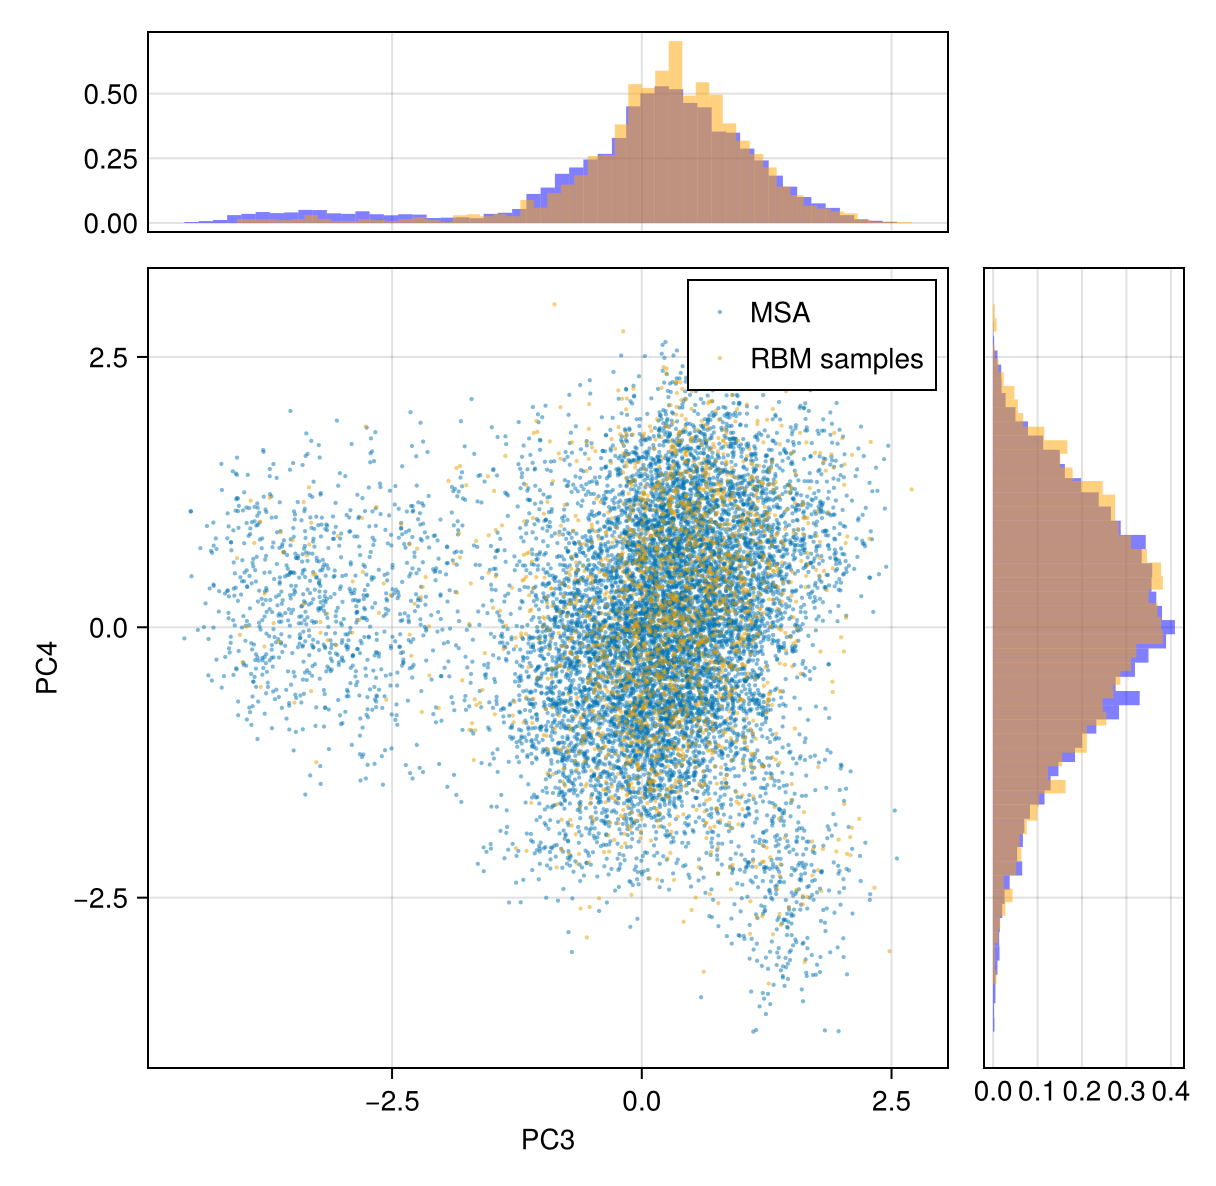

In [38]:
# pca projection of data vs generated samples with marginal histograms - PC3 vs PC4

using MultivariateStats

# Select subset of data (10000 samples)
nsamples_data = min(10000, size(msa_onehot, 3))
data_subset = msa_onehot[:, :, 1:nsamples_data]

# Flatten the data for PCA
data_flat = reshape(cpu(data_subset), :, size(data_subset, 3))'
sampled_flat = reshape(cpu(sampled_v), :, size(sampled_v, 3))'

# Fit PCA on the real data with at least 4 components
M = fit(PCA, data_flat'; maxoutdim=4)

# Transform both datasets
data_proj = predict(M, data_flat')'
sampled_proj = predict(M, sampled_flat')'

# Plot with marginal histograms - PC3 vs PC4
fig = Figure()
ax_main = Axis(fig[2,1], width=400, height=400, xlabel="PC3", ylabel="PC4")
ax_top = Axis(fig[1,1], width=400, height=100, xticklabelsvisible=false, xticksvisible=false, yticksvisible=false)
ax_right = Axis(fig[2,2], width=100, height=400, yticklabelsvisible=false, yticksvisible=false, xticksvisible=false)

# Main scatter plot
scatter!(ax_main, data_proj[:, 3], data_proj[:, 4]; markersize=3, label="MSA", alpha=0.5)
scatter!(ax_main, sampled_proj[:, 3], sampled_proj[:, 4]; markersize=3, label="RBM samples", alpha=0.5)

# Top histogram (PC3) - normalized
hist!(ax_top, data_proj[:, 3]; bins=50, color=(:blue, 0.5), normalization=:pdf)
hist!(ax_top, sampled_proj[:, 3]; bins=50, color=(:orange, 0.5), normalization=:pdf)

# Right histogram (PC4) - normalized
hist!(ax_right, data_proj[:, 4]; bins=50, direction=:x, color=(:blue, 0.5), normalization=:pdf)
hist!(ax_right, sampled_proj[:, 4]; bins=50, direction=:x, color=(:orange, 0.5), normalization=:pdf)

axislegend(ax_main, position=:rt)
resize_to_layout!(fig)
fig